<a href="https://colab.research.google.com/github/Ariel-Pineapple/qc-anomaly-detection-isolation-forest/blob/main/02_baselie_westgard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

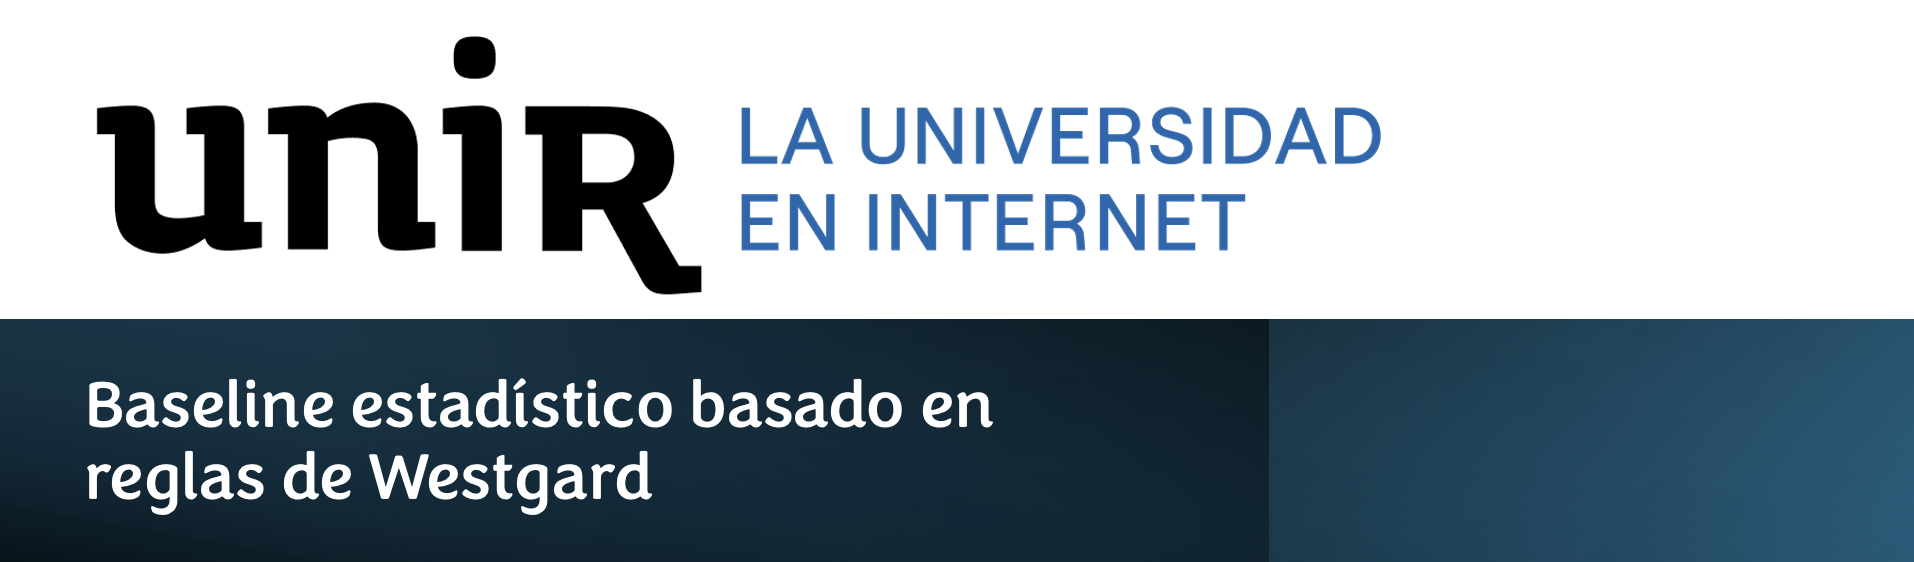

# Baseline estadístico basado en reglas de Westgard

**Proyecto:** Detección de anomalías en control de calidad de inmunoensayos  
**Modelo comparativo:** Reglas de Westgard  
**Autor(es):** Equipo 3004D  
**Fecha:** 2026

---

## Objetivo

Implementar un baseline estadístico interpretable basado en reglas de Westgard para detectar desviaciones en valores S/CO, generando alertas explicables y comparables con el modelo de detección de anomalías propuesto.

---

## Alcance

En esta etapa se implementan las reglas 1-2s, 1-3s y 2-2s, seleccionadas por su relevancia en control de calidad y su utilidad como referencia comparativa para la validación posterior del modelo Isolation Forest.

Las reglas de Westgard constituyen un conjunto de criterios estadísticos ampliamente utilizados en control de calidad clínico para detectar errores sistemáticos y aleatorios en mediciones analíticas.

## Importación de Librerías

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

plt.style.use("default")
sns.set_theme()
pd.set_option("display.max_columns", None)

## 1. Carga del dataset

Se carga el dataset sintético previamente validado en el EDA, el cual contiene registros normales y segmentos con drift controlado.

In [19]:
df = pd.read_csv("dataset_qc_sintetico.csv")
df["fecha"] = pd.to_datetime(df["fecha"])

df.head()

,id_registro,fecha,analito,lote,equipo,sco,estado_real,tipo_drift
0,1,2025-01-01,VIH,L001,E01,1.0248,0,normal
1,2,2025-01-02,VIH,L001,E01,0.9931,0,normal
2,3,2025-01-03,VIH,L001,E01,1.0324,0,normal
3,4,2025-01-04,VIH,L001,E01,1.0762,0,normal
4,5,2025-01-05,VIH,L001,E01,0.9883,0,normal


## 2. Definición de línea base estadística

Para implementar las reglas de Westgard se requiere una media de referencia y una desviación estándar. En este ejercicio se calcularán a partir de un segmento inicial considerado estable.

Se selecciona un tamaño de ventana inicial de 80 observaciones como segmento estable, asumiendo que corresponde a condiciones normales del proceso. Este valor permite estimar de forma robusta la media y desviación estándar sin incluir segmentos con drift.

In [20]:
baseline_window = 80

media_ref = df.loc[:baseline_window-1, "sco"].mean()
std_ref = df.loc[:baseline_window-1, "sco"].std()

media_ref, std_ref

(np.float64(0.9938075000000002), 0.047875671724143726)

## 3. Cálculo de desviación estandarizada

Cada observación se transforma a z-score para evaluar su distancia respecto a la media de referencia.

In [21]:
df["media_ref"] = media_ref
df["std_ref"] = std_ref
df["z_score"] = (df["sco"] - media_ref) / std_ref

df.head()

,id_registro,fecha,analito,lote,equipo,sco,estado_real,tipo_drift,media_ref,std_ref,z_score
0,1,2025-01-01,VIH,L001,E01,1.0248,0,normal,0.993808,0.047876,0.647354
1,2,2025-01-02,VIH,L001,E01,0.9931,0,normal,0.993808,0.047876,-0.014778
2,3,2025-01-03,VIH,L001,E01,1.0324,0,normal,0.993808,0.047876,0.806098
3,4,2025-01-04,VIH,L001,E01,1.0762,0,normal,0.993808,0.047876,1.720968
4,5,2025-01-05,VIH,L001,E01,0.9883,0,normal,0.993808,0.047876,-0.115038


## 4. Regla 1-2s

La regla 1-2s se interpreta como señal de advertencia cuando un resultado excede dos desviaciones estándar respecto a la media.

In [22]:
df["flag_12s"] = (df["z_score"].abs() > 2).astype(int)

## 5. Regla 1-3s

La regla 1-3s identifica resultados fuera de control cuando la desviación supera tres desviaciones estándar.

In [23]:
df["flag_13s"] = (df["z_score"].abs() > 3).astype(int)

## 6. Regla 2-2s

La regla 2-2s se activa cuando dos observaciones consecutivas exceden dos desviaciones estándar en el mismo lado de la media.

In [24]:
df["flag_22s"] = 0

for i in range(1, len(df)):
    actual = df.loc[i, "z_score"]
    previo = df.loc[i-1, "z_score"]

    if actual > 2 and previo > 2:
        df.loc[i, "flag_22s"] = 1
    elif actual < -2 and previo < -2:
        df.loc[i, "flag_22s"] = 1

Es importante notar que las reglas de Westgard no son mutuamente excluyentes; una misma observación puede activar múltiples reglas simultáneamente. Por ello, la suma de activaciones individuales puede exceder el número total de alertas.

## 7. Consolidación del baseline

Se genera una alerta global cuando al menos una de las reglas implementadas se activa.

In [25]:
df["westgard_alert"] = (
    (df["flag_12s"] == 1) |
    (df["flag_13s"] == 1) |
    (df["flag_22s"] == 1)
).astype(int)

In [26]:
def severity(row):
    if row["flag_13s"] == 1 or row["flag_22s"] == 1:
        return "critical"
    elif row["flag_12s"] == 1:
        return "warning"
    return "normal"

df["westgard_severity"] = df.apply(severity, axis=1)

## 8. Explicabilidad del baseline

Además de la bandera de alerta, se documenta qué regla específica se activó y una explicación textual del motivo.

In [27]:
def identify_rule(row):
    reglas = []
    if row["flag_13s"] == 1:
        reglas.append("1-3s")
    if row["flag_22s"] == 1:
        reglas.append("2-2s")
    if row["flag_12s"] == 1 and row["flag_13s"] == 0:
        reglas.append("1-2s")
    return ", ".join(reglas) if reglas else "Ninguna"

def explain_rule(row):
    if row["flag_13s"] == 1:
        return f"z={row['z_score']:.2f}: excede ±3σ (fuera de control)"
    elif row["flag_22s"] == 1:
        return f"z actual={row['z_score']:.2f} y previo exceden ±2σ en misma dirección"
    elif row["flag_12s"] == 1:
        return f"z={row['z_score']:.2f}: excede ±2σ (advertencia)"
    else:
        return "Sin evidencia de violación"

df["westgard_rule_triggered"] = df.apply(identify_rule, axis=1)
df["westgard_explanation"] = df.apply(explain_rule, axis=1)

df[["fecha", "sco", "z_score", "flag_12s", "flag_13s", "flag_22s", "westgard_alert", "westgard_rule_triggered", "westgard_explanation"]].head(15)

,fecha,sco,z_score,flag_12s,flag_13s,flag_22s,westgard_alert,westgard_rule_triggered,westgard_explanation
0,2025-01-01,1.0248,0.647354,0,0,0,0,Ninguna,Sin evidencia de violación
1,2025-01-02,0.9931,-0.014778,0,0,0,0,Ninguna,Sin evidencia de violación
2,2025-01-03,1.0324,0.806098,0,0,0,0,Ninguna,Sin evidencia de violación
3,2025-01-04,1.0762,1.720968,0,0,0,0,Ninguna,Sin evidencia de violación
4,2025-01-05,0.9883,-0.115038,0,0,0,0,Ninguna,Sin evidencia de violación
5,2025-01-06,0.9883,-0.115038,0,0,0,0,Ninguna,Sin evidencia de violación
6,2025-01-07,1.0790,1.779453,0,0,0,0,Ninguna,Sin evidencia de violación
7,2025-01-08,1.0384,0.931423,0,0,0,0,Ninguna,Sin evidencia de violación
8,2025-01-09,0.9765,-0.361509,0,0,0,0,Ninguna,Sin evidencia de violación
9,2025-01-10,1.0271,0.695395,0,0,0,0,Ninguna,Sin evidencia de violación


## 9. Visualización temporal de alertas

Se representan las alertas del baseline sobre la serie temporal para evaluar si las reglas detectan los segmentos anómalos inyectados.

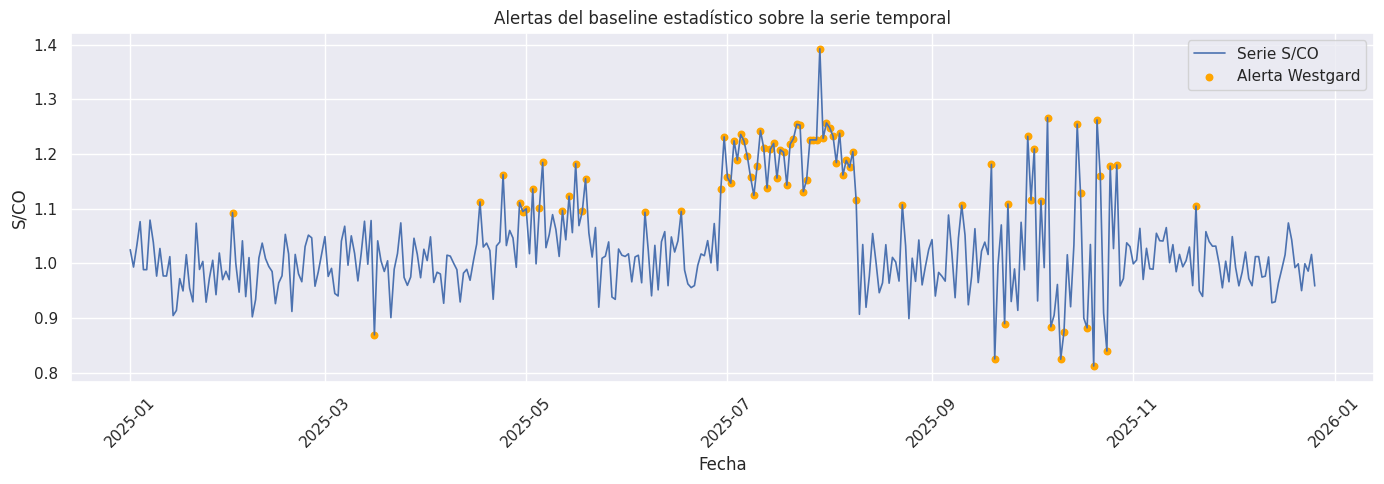

In [28]:
plt.figure(figsize=(14,5))
plt.plot(df["fecha"], df["sco"], label="Serie S/CO", linewidth=1.2)

alerts = df[df["westgard_alert"] == 1]
plt.scatter(alerts["fecha"], alerts["sco"], color="orange", label="Alerta Westgard", s=22)

plt.title("Alertas del baseline estadístico sobre la serie temporal")
plt.xlabel("Fecha")
plt.ylabel("S/CO")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

## 10. Resumen de desempeño del baseline

Se resume cuántas alertas fueron emitidas por cada regla y su distribución general.

In [29]:
df["westgard_rule_triggered"].value_counts()

,count
westgard_rule_triggered,
Ninguna,277
"1-3s, 2-2s",42
1-2s,20
1-3s,13
"2-2s, 1-2s",8


In [30]:
resumen_reglas = {
    "1-2s": int(df["flag_12s"].sum()),
    "1-3s": int(df["flag_13s"].sum()),
    "2-2s": int(df["flag_22s"].sum()),
    "Alertas totales": int(df["westgard_alert"].sum())
}

pd.DataFrame(list(resumen_reglas.items()), columns=["Regla", "Frecuencia"])

,Regla,Frecuencia
0,1-2s,83
1,1-3s,55
2,2-2s,50
3,Alertas totales,83


## 11. Comparación preliminar con etiquetas reales

Se realiza una comparación inicial entre las alertas del baseline y la etiqueta `estado_real`, con fines exploratorios previos a la validación formal.

In [31]:
pd.crosstab(df["estado_real"], df["westgard_alert"], rownames=["Estado real"], colnames=["Alerta Westgard"])

Alerta Westgard,0,1
Estado real,,
0,231,9
1,46,74


El baseline identifica correctamente 74 de 120 anomalías (recall ≈ 0.62), lo que indica una capacidad moderada de detección. Asimismo, presenta 9 falsas alarmas sobre 240 observaciones normales (FAR ≈ 0.04), lo que sugiere un bajo nivel de alertas innecesarias.

Estos resultados reflejan el comportamiento esperado de reglas estadísticas tradicionales: buena precisión, pero menor sensibilidad ante anomalías sutiles.

## 12. Métricas exploratorias del baseline

Se calcula de manera preliminar el recall y la tasa de falsas alarmas del baseline, los cuales servirán de referencia para la comparación posterior con Isolation Forest.

In [32]:
tp = ((df["estado_real"] == 1) & (df["westgard_alert"] == 1)).sum()
fn = ((df["estado_real"] == 1) & (df["westgard_alert"] == 0)).sum()
fp = ((df["estado_real"] == 0) & (df["westgard_alert"] == 1)).sum()
tn = ((df["estado_real"] == 0) & (df["westgard_alert"] == 0)).sum()

recall = tp / (tp + fn) if (tp + fn) > 0 else 0
far = fp / (fp + tn) if (fp + tn) > 0 else 0

print(f"Recall del baseline: {recall:.4f}")
print(f"Tasa de falsas alarmas (FAR): {far:.4f}")

Recall del baseline: 0.6167
Tasa de falsas alarmas (FAR): 0.0375


Este baseline servirá como referencia comparativa para evaluar si el modelo basado en Isolation Forest logra mejorar la sensibilidad en la detección de anomalías sin incrementar significativamente la tasa de falsas alarmas.

## 13. Conclusiones del baseline

El baseline estadístico implementado permite generar alertas totalmente explicables, indicando de forma explícita qué regla se activó y por qué. Esta trazabilidad lo convierte en una referencia adecuada para comparar el desempeño del modelo de detección de anomalías.

Asimismo, el análisis preliminar de recall y tasa de falsas alarmas ofrece un punto de partida cuantitativo para evaluar si Isolation Forest aporta una mejora real en sensibilidad y reducción de alertas innecesarias.